# Data Extraction

In [24]:
import requests
from bs4 import BeautifulSoup
import argparse
from urllib.parse import urlparse
import subprocess
import os
import tempfile
import json
import sys
import pickle
import pandas as pd
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [25]:
df = pd.DataFrame()
with open("../results/results_full_part2.pkl", 'rb') as f:
    df = pickle.load(f)

In [26]:
df.sample(1)

,Rev-License-Path,Snap-License-Path,Rev-License-Scanned,Snap-License-Scanned
1003,https://archive.softwareheritage.org/browse/revision/1960f0c2db99c2b04bd87a6e6f604c5dbacb3bc6/?path=actiontext/MIT-LICENSE,https://archive.softwareheritage.org/browse/snapshot/9fd3479e95e7ba013aa400eca4a49c396f52459d/directory/?branch=refs/heads/main&path=actiontext/MIT-LICENSE,mit,mit


In [27]:
df_without_na = df.loc[~df['Rev-License-Scanned'].isna() & ~df['Snap-License-Scanned'].isna()]
print(f'Out of {len(df)} changed license detected, {len(df)-len(df_without_na)} didn\'t have both licenses scanned')

Out of 4147 changed license detected, 650 didn't have both licenses scanned


In [28]:
df_diff = df_without_na.loc[df_without_na['Rev-License-Scanned'] != df_without_na['Snap-License-Scanned']]
print(f'{len(df_diff)} cases of license change detected')

555 cases of license change detected


In [29]:
df_diff.head()

,Rev-License-Path,Snap-License-Path,Rev-License-Scanned,Snap-License-Scanned
29,https://archive.softwareheritage.org/browse/revision/5fc3cdf857ab654f6a519f9c4d66ef60d397815e/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/07b3def11887046e9939f02fd7dd480a96741e7e/directory/?branch=refs/heads/main&path=LICENSE,mit,gpl-3.0
30,https://archive.softwareheritage.org/browse/revision/443e54adfc879787401617a763cd02b621b546a9/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/63ad5f4f196b35f2d22ed9d80186f30c2beea7cf/directory/?branch=refs/heads/main&path=LICENSE,mit,apache-2.0
34,https://archive.softwareheritage.org/browse/revision/116b11e6a17e89d54616d182bcd9f251ce66f543/?path=LICENSE.md,https://archive.softwareheritage.org/browse/snapshot/a9bb95449fba819448baece724dec6030925770f/directory/?branch=refs/heads/main&path=LICENSE.md,mit,bsd-new
35,https://archive.softwareheritage.org/browse/revision/8eea4b898dd582f0f8cb3571c919ee77ac56daac/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/89255770a633943c3d0aec49de1c0f30b1ab589f/directory/?branch=refs/heads/main&path=LICENSE,unlicense,isc
38,https://archive.softwareheritage.org/browse/revision/5dd8caca7d81161eb719f419c1d02230f11f5582/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/7f70ab812e956e590909946864c8871b3905f2bf/directory/?branch=refs/heads/main&path=LICENSE,apache-2.0,mit


In [30]:
df_changes = df_diff[['Rev-License-Scanned', 'Snap-License-Scanned']].drop_duplicates()
len(df_changes)

145

In [21]:
df_changes.sample(2)

,Rev-License-Scanned,Snap-License-Scanned
1581,lgpl-2.1-plus,lgpl-2.1
2585,gpl-3.0,gpl-3.0-plus


In [22]:
output_path = "../results/license_changes.xlsx"
df_changes.to_excel(output_path, index=False)
print(f"DataFrame exported successfully to {output_path}")

DataFrame exported successfully to ../results/license_changes.xlsx


# Precaution Level

In [ ]:
df_diff = df_diff.rename(columns={
    'Rev-License-Scanned': 'from_license',
    'Snap-License-Scanned': 'to_license'
})

In [34]:
license_changes_class = pd.read_excel("../results/license_changes_class.xlsx")

In [47]:
df_classified = df_diff.merge(
    license_changes_class,
    on=['from_license', 'to_license'],
    how='left'
)
df_classified.sample(5)

,Rev-License-Path,Snap-License-Path,from_license,to_license,from_category,to_category,precaution_level
463,https://archive.softwareheritage.org/browse/revision/83f719afaf82e33c0e3bf6b29cd2684bedcd60dc/?path=LICENSE.txt,https://archive.softwareheritage.org/browse/snapshot/424882bec423cebbe3fed12066cff39de615207e/directory/?branch=refs/heads/main&path=LICENSE.txt,cc-by-3.0,mit,cc-by,permissive,Medium
441,https://archive.softwareheritage.org/browse/revision/6026e38997aa169b02b15bc2f9a7743f77350e5f/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/2f4ac83ddac8a906e803a0fb660392dfb9d37ca0/directory/?branch=refs/heads/main&path=LICENSE,apache-2.0,mit,permissive,permissive,Low
24,https://archive.softwareheritage.org/browse/revision/5a6da167af7b9f69df833bb5c9f7e63cd9193efa/?path=LICENSE.txt,https://archive.softwareheritage.org/browse/snapshot/a7c8bc258e2a5eb4ce69830b2f2c5cde45fdcaff/directory/?branch=refs/heads/main&path=LICENSE.txt,tanuki-community-sla-1.3,bsd-simplified,special,permissive,High - Needs Legal Review
447,https://archive.softwareheritage.org/browse/revision/0fc9f9340f6a83c0e0428c049cfec95c88efd2d7/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/f5180fe428af1168fcbcd7e235ba61f9667b5274/directory/?branch=refs/heads/main&path=LICENSE,bsd-new,mit,permissive,permissive,Low
400,https://archive.softwareheritage.org/browse/revision/7de638a96cdb5b4df33e861f79ff5642c99e2e82/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/c4d1b9328d0abb33dfe82ba3d71c84e023695338/directory/?branch=refs/heads/main&path=LICENSE,gpl-3.0,apache-2.0,strong_copyleft,permissive,Medium


In [36]:
output_path = "../results/precaution_results.xlsx"
df_classified.to_excel(output_path, index=False)
print(f"DataFrame exported successfully to {output_path}")

DataFrame exported successfully to ../results/precaution_results.xlsx


In [41]:
ds = pd.read_csv("../results/repos_modified_full.csv", delimiter=';')
ds.head()

,origin,revision,snapshot_without,path,Rev-License-Path,Snap-License-Path,amount_contrib,amount_author,amount_committer,amount_snap,amount_rel,amount_rev,freq_snap,freq_rev
0,https://github.com/cloudmesh/cloudmesh-google,swh:1:rev:b5f19db0568959b81d8dcb0402d35cd64e680d30,swh:1:snp:627839659fc4a3aac1c53f78cb3326d39715c804,./LICENSE,https://archive.softwareheritage.org/browse/revision/b5f19db0568959b81d8dcb0402d35cd64e680d30/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/627839659fc4a3aac1c53f78cb3326d39715c804/directory/?branch=refs/heads/main&path=LICENSE,9,8,8,3,0,43,"0,002117149","0,030345801"
1,https://github.com/benjcabalona1029/benjcabalona1029.github.io,swh:1:rev:ce005be7fe4254065d06cf355df18189f2c510c5,swh:1:snp:4222b06c76d570b02fa89a348fd46e5ee790b48f,./LICENSE,https://archive.softwareheritage.org/browse/revision/ce005be7fe4254065d06cf355df18189f2c510c5/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/4222b06c76d570b02fa89a348fd46e5ee790b48f/directory/?branch=refs/heads/main&path=LICENSE,6,5,3,3,0,62,"0,002056203","0,042494859"
2,https://github.com/physixcat/knr,swh:1:rev:1f24ac997775d7d82c37849c9ab740c5165806c8,swh:1:snp:03a50be8b03cb811c9c2a7c1d50ddf8e0226931a,./LICENSE,https://archive.softwareheritage.org/browse/revision/1f24ac997775d7d82c37849c9ab740c5165806c8/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/03a50be8b03cb811c9c2a7c1d50ddf8e0226931a/directory/?branch=refs/heads/main&path=LICENSE,1,1,1,3,0,5,"0,023255814","0,03875969"
3,https://gitlab.com/vojta_vogo/OttoHumanoidNG.git,swh:1:rev:a4ff66fd728612f6e163c3cfa3f3ec468d224275,swh:1:snp:9256442171c260c256ba4677776791925df099c6,./LICENSE,https://archive.softwareheritage.org/browse/revision/a4ff66fd728612f6e163c3cfa3f3ec468d224275/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/9256442171c260c256ba4677776791925df099c6/directory/?branch=refs/heads/main&path=LICENSE,1,1,1,3,0,5,"0,022556391","0,037593985"
4,https://github.com/jonkoops/keycloak,swh:1:rev:8a405ed83c5b6340af2d092e61db5f2b851e5591,swh:1:snp:236ac4c2de396f53e14bedd347bf26782ada169c,./distribution/galleon-feature-packs/saml-adapter-galleon-pack/src/main/resources/license/licenses.xml,https://archive.softwareheritage.org/browse/revision/8a405ed83c5b6340af2d092e61db5f2b851e5591/?path=distribution/galleon-feature-packs/saml-adapter-galleon-pack/src/main/resources/license/licenses.xml,https://archive.softwareheritage.org/browse/snapshot/236ac4c2de396f53e14bedd347bf26782ada169c/directory/?branch=refs/heads/main&path=distribution/galleon-feature-packs/saml-adapter-galleon-pack/src/main/resources/license/licenses.xml,1579,1574,306,42,1680,13807,"0,027962716","9,19241012"


In [43]:
df_classified_full = ds.merge(
    df_classified,
    on=['Rev-License-Path', 'Snap-License-Path'],
    how='left'
)

In [52]:
df_with_precaution = df_classified_full.dropna(subset=['precaution_level'])

In [53]:
high = df_with_precaution.loc[df_with_precaution['precaution_level'] == "High"]
print(f'amount of license change with a high precaution level: {len(high)}')
high.head()

amount of license change with a high precaution level: 118


,origin,revision,snapshot_without,path,Rev-License-Path,Snap-License-Path,amount_contrib,amount_author,amount_committer,amount_snap,amount_rel,amount_rev,freq_snap,freq_rev,from_license,to_license,from_category,to_category,precaution_level
29,https://github.com/YHYJ/MyBlogs,swh:1:rev:5fc3cdf857ab654f6a519f9c4d66ef60d397815e,swh:1:snp:07b3def11887046e9939f02fd7dd480a96741e7e,./LICENSE,https://archive.softwareheritage.org/browse/revision/5fc3cdf857ab654f6a519f9c4d66ef60d397815e/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/07b3def11887046e9939f02fd7dd480a96741e7e/directory/?branch=refs/heads/main&path=LICENSE,11,10,10,11,0,31,"0,008403361","0,0236822",mit,gpl-3.0,permissive,strong_copyleft,High
42,https://gitlab.com/Eyap/gamelibrary.scenemanagement.git,swh:1:rev:f7476f300a1ec2250025d8aa43262810ad1dbf48,swh:1:snp:212428e8693ff2ed0bb28bff3fca5a0ad19b35b6,./LICENSE.md,https://archive.softwareheritage.org/browse/revision/f7476f300a1ec2250025d8aa43262810ad1dbf48/?path=LICENSE.md,https://archive.softwareheritage.org/browse/snapshot/212428e8693ff2ed0bb28bff3fca5a0ad19b35b6/directory/?branch=refs/heads/main&path=LICENSE.md,1,1,1,3,5,37,"0,023622047","0,291338583",mit,mpl-2.0,permissive,weak_copyleft,High
104,https://github.com/fuspu/RHP-POS,swh:1:rev:f03412b0bef85f7bd343575a7c308cb65be4bdf0,swh:1:snp:947d956f84ea9a3a30f7f4b61b16daa165f56202,./LICENSE,https://archive.softwareheritage.org/browse/revision/f03412b0bef85f7bd343575a7c308cb65be4bdf0/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/947d956f84ea9a3a30f7f4b61b16daa165f56202/directory/?branch=refs/heads/main&path=LICENSE,5,4,4,15,0,257,"0,010578279","0,181241185",mit,gpl-3.0,permissive,strong_copyleft,High
113,https://github.com/iseeyo/alist,swh:1:rev:430b4cf723a79b315eeca02e574d7bb64cd2733e,swh:1:snp:4a4424fd6d3cd97e7e86eaed66876e19ae31efe0,./LICENSE,https://archive.softwareheritage.org/browse/revision/430b4cf723a79b315eeca02e574d7bb64cd2733e/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/4a4424fd6d3cd97e7e86eaed66876e19ae31efe0/directory/?branch=refs/heads/main&path=LICENSE,71,69,14,2,7,3,"0,666666667",1,mit,agpl-3.0,permissive,strong_copyleft,High
232,https://github.com/mstevenson888/epiR,swh:1:rev:8b26156e65daf16b77e343269e059ea85ff1487e,swh:1:snp:ecc85cfe1d4d7ea54684b48bd985b5422f25ec9c,./LICENSE,https://archive.softwareheritage.org/browse/revision/8b26156e65daf16b77e343269e059ea85ff1487e/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/ecc85cfe1d4d7ea54684b48bd985b5422f25ec9c/directory/?branch=refs/heads/main&path=LICENSE,3,2,2,6,0,49,"0,003821656","0,031210191",mit,gpl-3.0,permissive,strong_copyleft,High


Total license changes with precaution level: 555


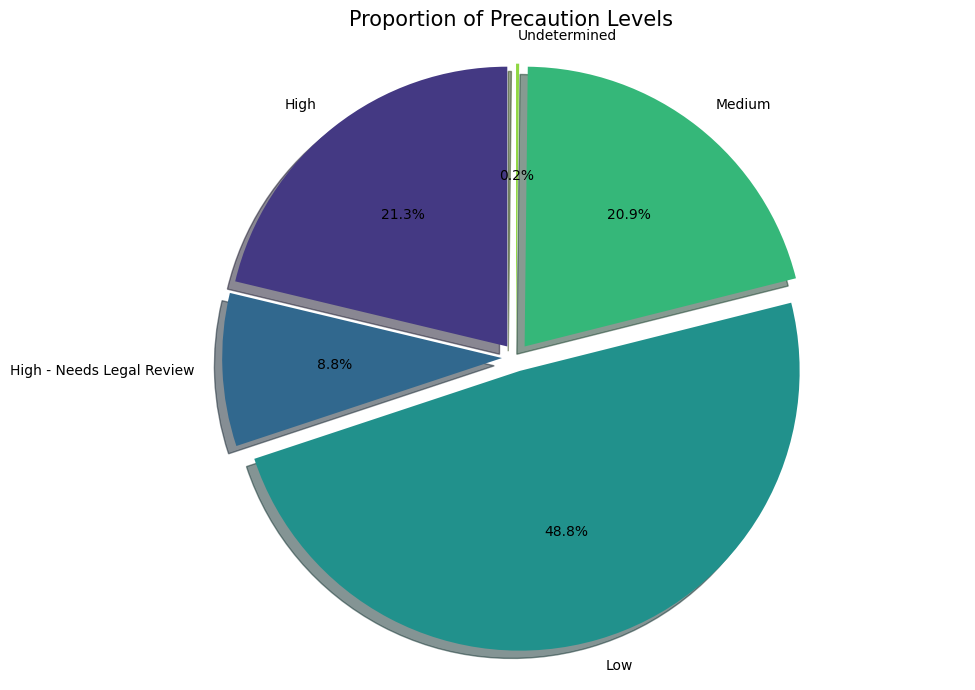

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Total license changes with precaution level: {len(df_with_precaution)}")
precaution_counts = df_with_precaution['precaution_level'].value_counts().sort_index()

# plt.figure(figsize=(10, 6))
# bar_plot = sns.barplot(x=precaution_counts.index, y=precaution_counts.values, palette='viridis', hue=precaution_counts.index)
# plt.title('Distribution of Precaution Levels', fontsize=15)
# plt.xlabel('Precaution Level', fontsize=12)
# plt.ylabel('Count', fontsize=12)
# plt.xticks(rotation=45)
# plt.tight_layout()

# for i, count in enumerate(precaution_counts.values):
#     bar_plot.text(i, count + 5, str(count), ha='center')

# plt.show()

plt.figure(figsize=(10, 7))
plt.pie(precaution_counts, labels=precaution_counts.index, autopct='%1.1f%%', 
        startangle=90, shadow=True, explode=[0.05] * len(precaution_counts),
        colors=sns.color_palette('viridis', len(precaution_counts)))
plt.title('Proportion of Precaution Levels', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

# print("\nPrecaution level distribution:")
# for level, count in precaution_counts.items():
#     percentage = (count / len(df_with_precaution)) * 100
#     print(f"- {level}: {count} ({percentage:.1f}%)")